
                                                                           
   # <center>Covid-19 in Italy </center>               

 # <center>by Ida Tateo</center>



1. Define the Research problem and associated questions.
2. Analyze the data by descriptive statistics and graphical visualization.
3. Prepare the data by using relevant preprocessing transformations, data cleaning, 
    data standardization, deaing with null and outlier values.

    

## 1. Define the Research problem and questions

**Research Questions:**  

    1.Create Sand Layer Charts to detect patterns of Covid-19 trends in Italy from the beginning of the pandemic to December 2020.

**Data Source:**
     I downloaded the dataset of Covid-19 in Italy by region from Kaggle.


In [4]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



## 2. Analyze the data using descriptive statistics and graphical visualizations.

In [6]:
# Filter warnings 
import warnings
warnings.filterwarnings('ignore')

# Read in the raw dataset, print the shape and first 5 rows.
covidinitaly = pd.read_csv('covid19_italy_region.csv')
print(covidinitaly.shape)
print(covidinitaly.head())


(6027, 17)
   SNo                 Date Country  RegionCode      RegionName   Latitude  \
0    0  2020-02-24T18:00:00     ITA          13         Abruzzo  42.351222   
1    1  2020-02-24T18:00:00     ITA          17      Basilicata  40.639471   
2    2  2020-02-24T18:00:00     ITA          18        Calabria  38.905976   
3    3  2020-02-24T18:00:00     ITA          15        Campania  40.839566   
4    4  2020-02-24T18:00:00     ITA           8  Emilia-Romagna  44.494367   

   Longitude  HospitalizedPatients  IntensiveCarePatients  \
0  13.398438                     0                      0   
1  15.805148                     0                      0   
2  16.594402                     0                      0   
3  14.250850                     0                      0   
4  11.341721                    10                      2   

   TotalHospitalizedPatients  HomeConfinement  CurrentPositiveCases  \
0                          0                0                     0   
1          

In [7]:
# Print the datatypes which are keys.
types = covidinitaly.dtypes
print(types)
print("Keys of Covid in Italy dataset:\n", covidinitaly.keys())

SNo                            int64
Date                          object
Country                       object
RegionCode                     int64
RegionName                    object
Latitude                     float64
Longitude                    float64
HospitalizedPatients           int64
IntensiveCarePatients          int64
TotalHospitalizedPatients      int64
HomeConfinement                int64
CurrentPositiveCases           int64
NewPositiveCases               int64
Recovered                      int64
Deaths                         int64
TotalPositiveCases             int64
TestsPerformed               float64
dtype: object
Keys of Covid in Italy dataset:
 Index(['SNo', 'Date', 'Country', 'RegionCode', 'RegionName', 'Latitude',
       'Longitude', 'HospitalizedPatients', 'IntensiveCarePatients',
       'TotalHospitalizedPatients', 'HomeConfinement', 'CurrentPositiveCases',
       'NewPositiveCases', 'Recovered', 'Deaths', 'TotalPositiveCases',
       'TestsPerformed'],
     

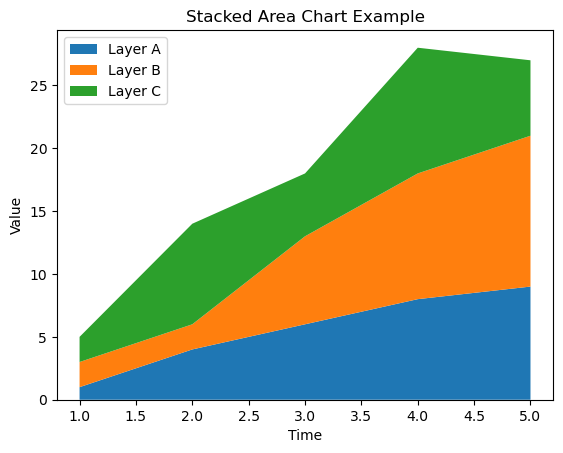

In [8]:
# Create data

x=range(1, 6)
y1=[1,4,6,8,9]
y2=[2,2,7,10,12]
y3=[2,8,5,10,6]

#Basic stacked area chart

plt.stackplot(x, y1, y2, y3, labels=['Layer A', 'Layer B', 'Layer C'])
plt.legend(loc='upper left')
plt.title('Stacked Area Chart Example')
plt.xlabel('Time')
plt.ylabel('Value')

plt.show()




(287, 21)
RegionName           Abruzzo  Basilicata  Calabria  Campania  Emilia-Romagna  \
Date                                                                           
2020-02-24 18:00:00        0           0         0         0              18   
2020-02-25 18:00:00        0           0         0         0              26   
2020-02-26 18:00:00        0           0         0         0              47   
2020-02-27 18:00:00        1           0         0         3              97   
2020-02-28 18:00:00        1           0         1         4             145   

RegionName           Friuli Venezia Giulia  Lazio  Liguria  Lombardia  Marche  \
Date                                                                            
2020-02-24 18:00:00                      0      3        0        172       0   
2020-02-25 18:00:00                      0      3        1        240       0   
2020-02-26 18:00:00                      0      3       11        258       1   
2020-02-27 18:00:00     

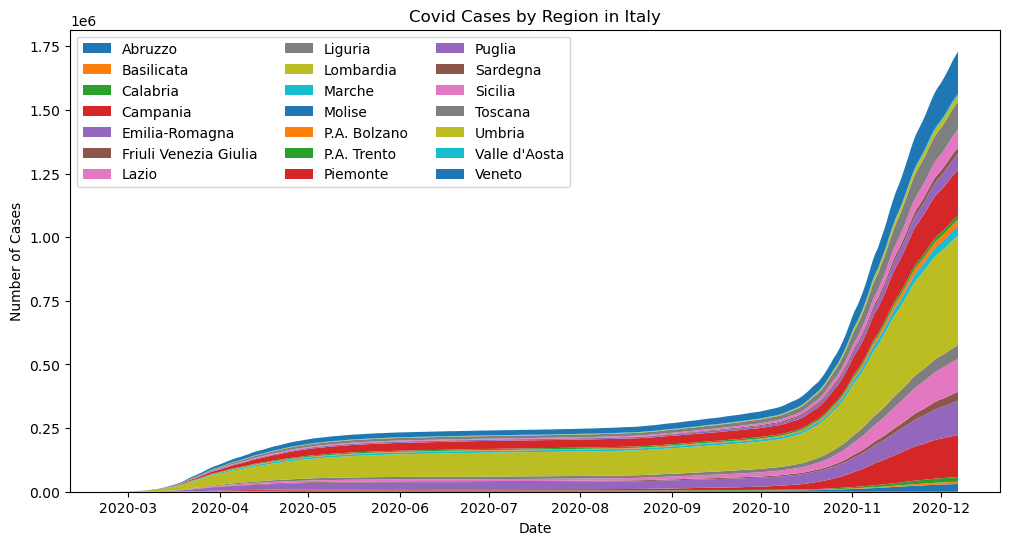

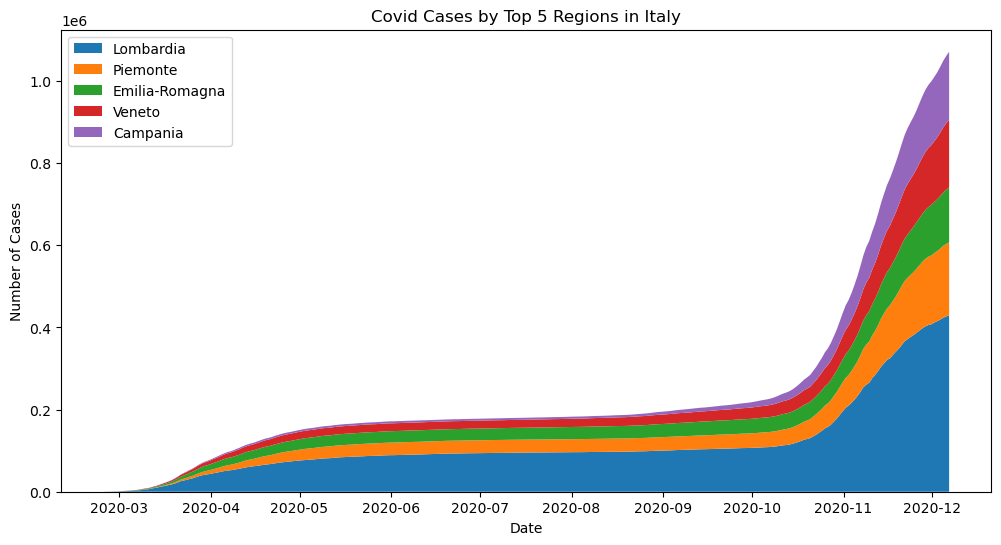

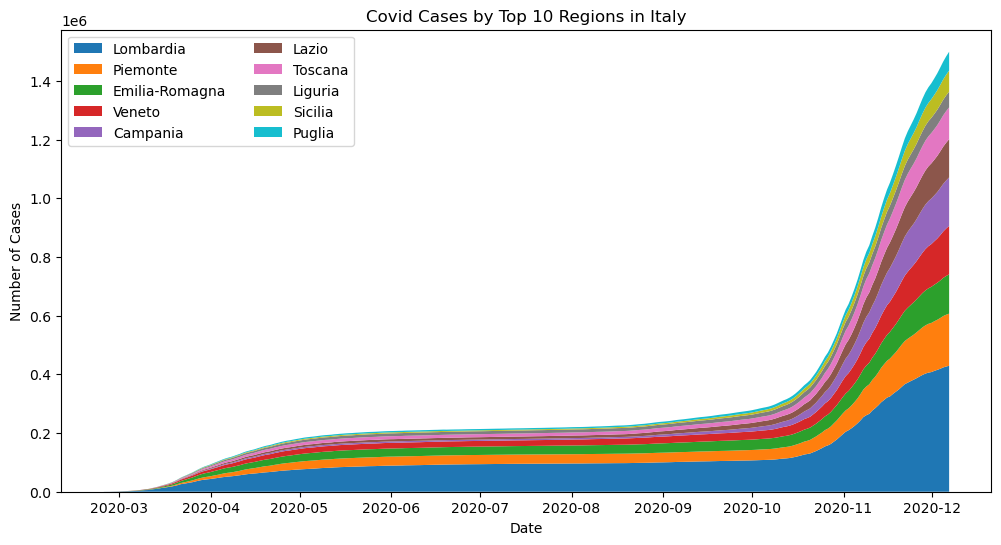

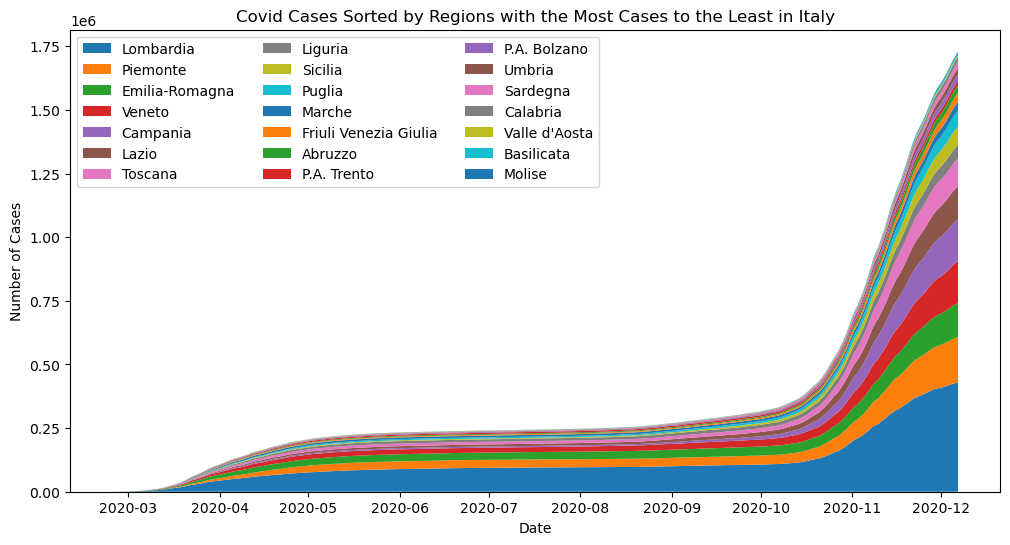

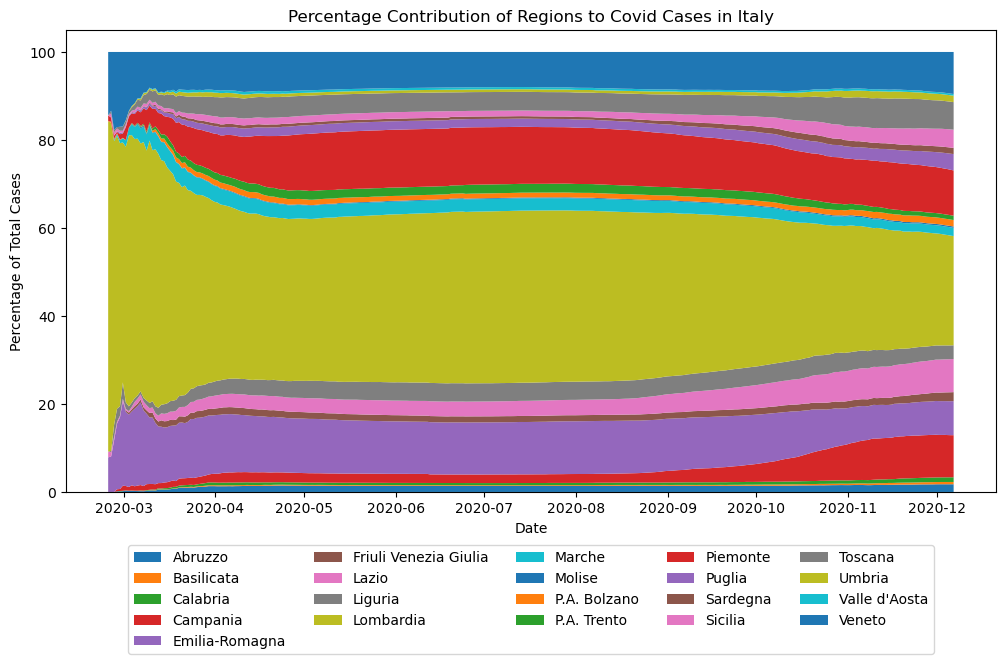

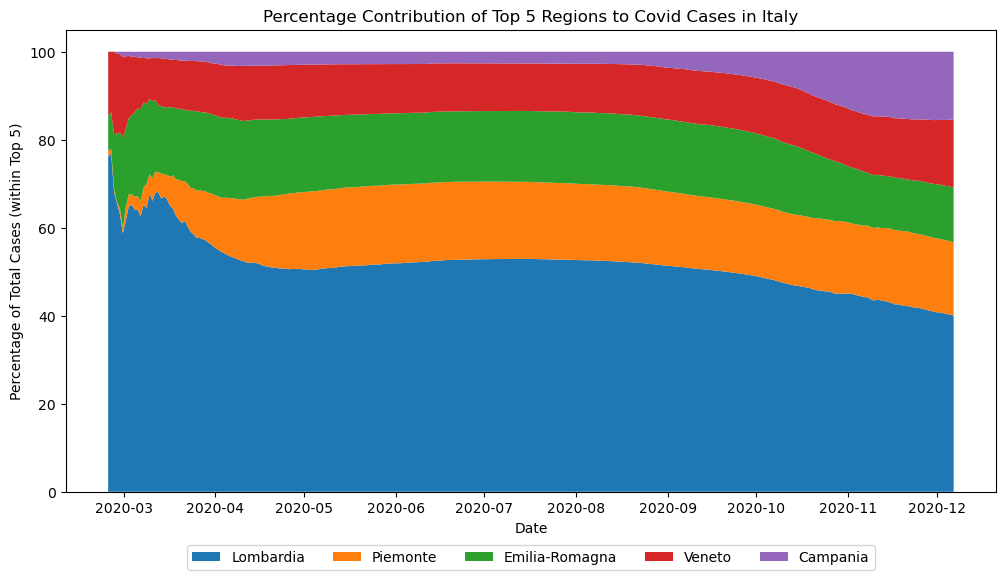

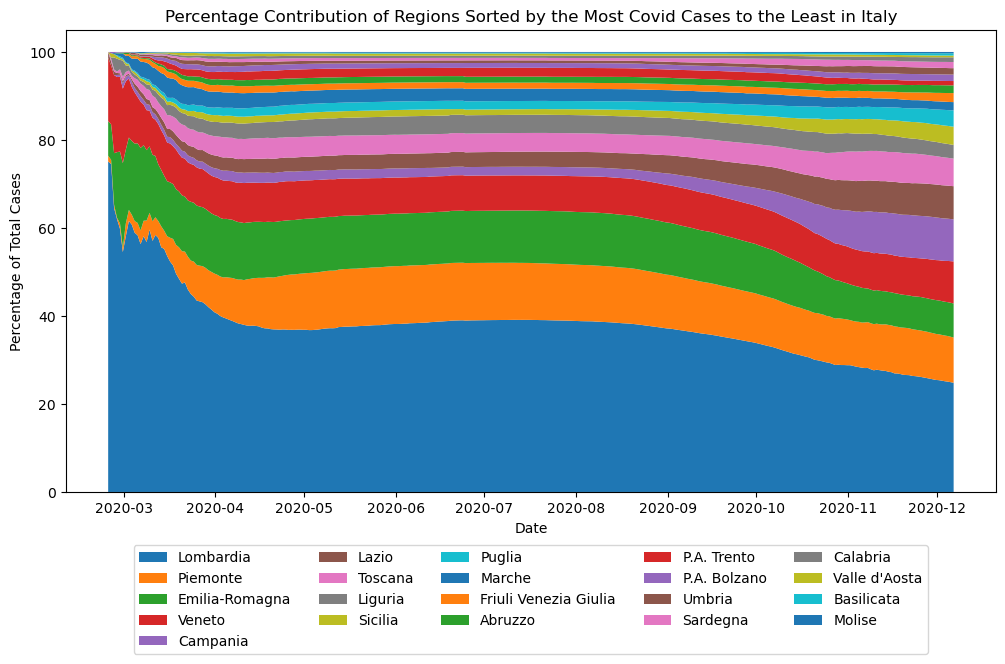

In [9]:

# create a covid dataset with date, region, and cases
covidinitaly_cases = covidinitaly[['Date', 'TotalPositiveCases', 'RegionName']]

# pivot to wide format (date x region table)
pivot_covidinitaly_cases = covidinitaly_cases.pivot(index="Date",columns="RegionName",values="TotalPositiveCases")

# change date index to datetime.
pivot_covidinitaly_cases.index=pd.to_datetime(pivot_covidinitaly_cases.index)

print(pivot_covidinitaly_cases.shape)
print(pivot_covidinitaly_cases.head())
print(pivot_covidinitaly_cases.tail())
print(pivot_covidinitaly_cases.describe().T)

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(pivot_covidinitaly_cases.index,
              pivot_covidinitaly_cases.T,
              labels=pivot_covidinitaly_cases.columns)
plt.title("Covid Cases by Region in Italy")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)
plt.show()

# select the top 5 regions in Italy with the most cases

# find the total cases per region
region_totals=pivot_covidinitaly_cases.sum().sort_values(ascending=False)

# select the top 5 regions
top5_regions=region_totals.head(5).index

# filter dataframe to those regions only
top5_data=pivot_covidinitaly_cases[top5_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top5_data.index,
              top5_data.T,
              labels=top5_data.columns)
plt.title("Covid Cases by Top 5 Regions in Italy")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left")
plt.show()

# select top 10 regions in Italy with the most cases

# select the top 10 regions
top10_regions=region_totals.head(10).index

# filter dataframe to those regions only
top10_data=pivot_covidinitaly_cases[top10_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top10_data.index,
              top10_data.T,
              labels=top10_data.columns)
plt.title("Covid Cases by Top 10 Regions in Italy")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=2)
plt.show()

# sort the regions in Italy with the most cases to the least

# select sorted regions
sorted_regions=region_totals.head(21).index

# filter dataframe to sorted regions
sorted_data=pivot_covidinitaly_cases[sorted_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(sorted_data.index,
              sorted_data.T,
              labels=sorted_data.columns)
plt.title("Covid Cases Sorted by Regions with the Most Cases to the Least in Italy")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)
plt.show()

# convert to percentages per day
covid_percent = pivot_covidinitaly_cases.div(pivot_covidinitaly_cases.sum(axis=1), axis=0) * 100

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(covid_percent.index,
              covid_percent.T,
              labels=covid_percent.columns)
plt.title("Percentage Contribution of Regions to Covid Cases in Italy")
plt.ylabel("Percentage of Total Cases")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()

# select the top N regions
N = 5
region_totals=pivot_covidinitaly_cases.sum().sort_values(ascending=False)
topN_regions =region_totals.head(N).index

# Filter only top N regions
topN_percent = pivot_covidinitaly_cases[topN_regions]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns)

plt.title(f"Percentage Contribution of Top {N} Regions to Covid Cases in Italy")
plt.ylabel("Percentage of Total Cases (within Top 5)")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()

# select the top N regions
N = 21
region_totals=pivot_covidinitaly_cases.sum().sort_values(ascending=False)
topN_regions =region_totals.head(N).index

# Filter only top N regions
topN_percent = pivot_covidinitaly_cases[topN_regions]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns)

plt.title("Percentage Contribution of Regions Sorted by the Most Covid Cases to the Least in Italy")
plt.ylabel("Percentage of Total Cases")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()


(287, 21)
RegionName           Abruzzo  Basilicata  Calabria  Campania  Emilia-Romagna  \
Date                                                                           
2020-02-24 18:00:00        0           0         0         0               0   
2020-02-25 18:00:00        0           0         0         0               0   
2020-02-26 18:00:00        0           0         0         0               1   
2020-02-27 18:00:00        0           0         0         0               1   
2020-02-28 18:00:00        0           0         0         0               2   

RegionName           Friuli Venezia Giulia  Lazio  Liguria  Lombardia  Marche  \
Date                                                                            
2020-02-24 18:00:00                      0      0        0          6       0   
2020-02-25 18:00:00                      0      0        0          9       0   
2020-02-26 18:00:00                      0      0        0          9       0   
2020-02-27 18:00:00     

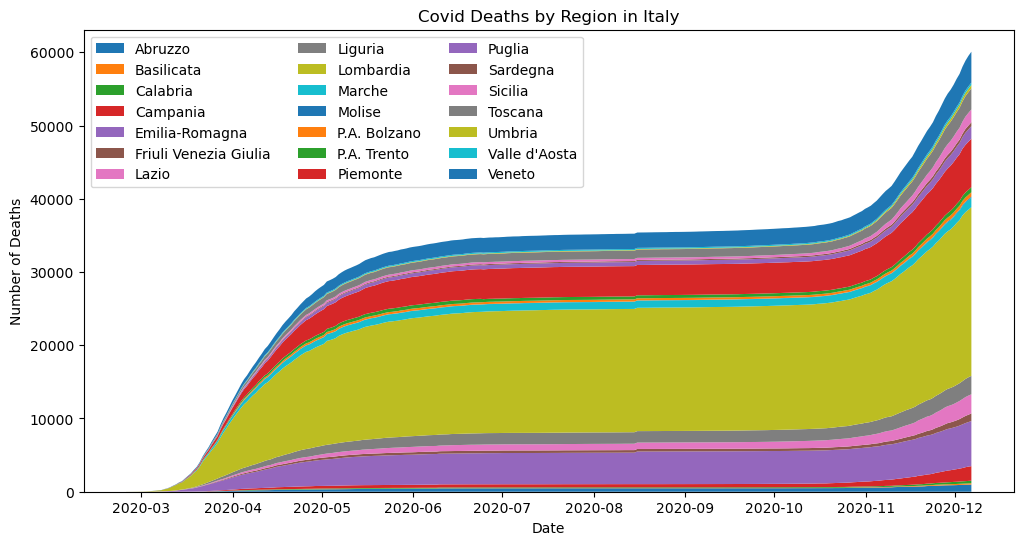

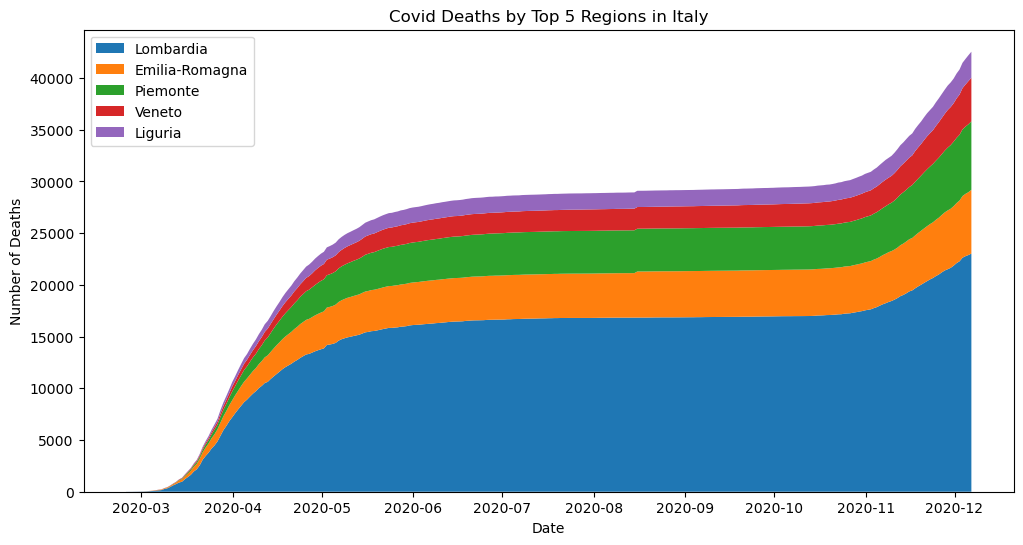

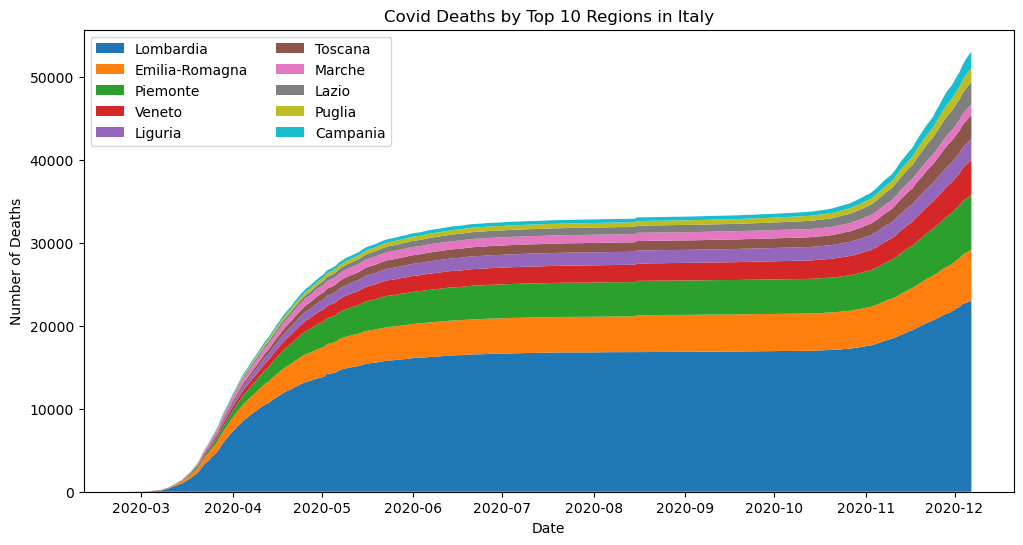

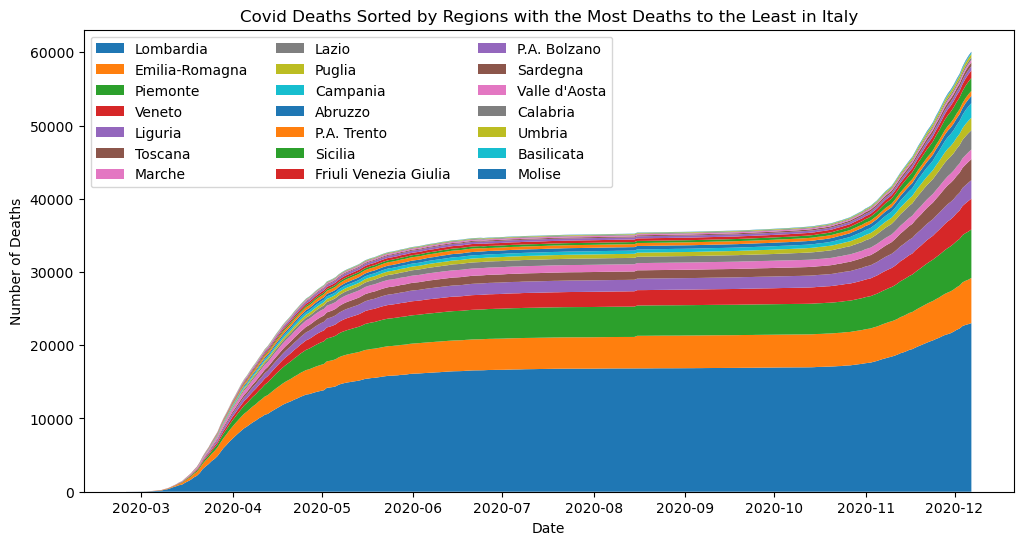

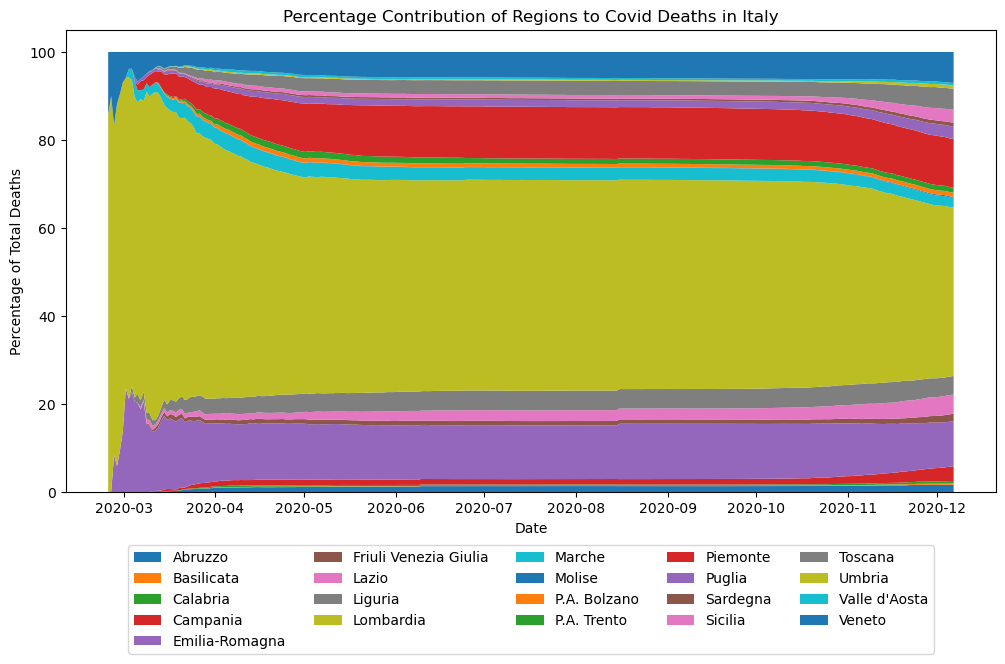

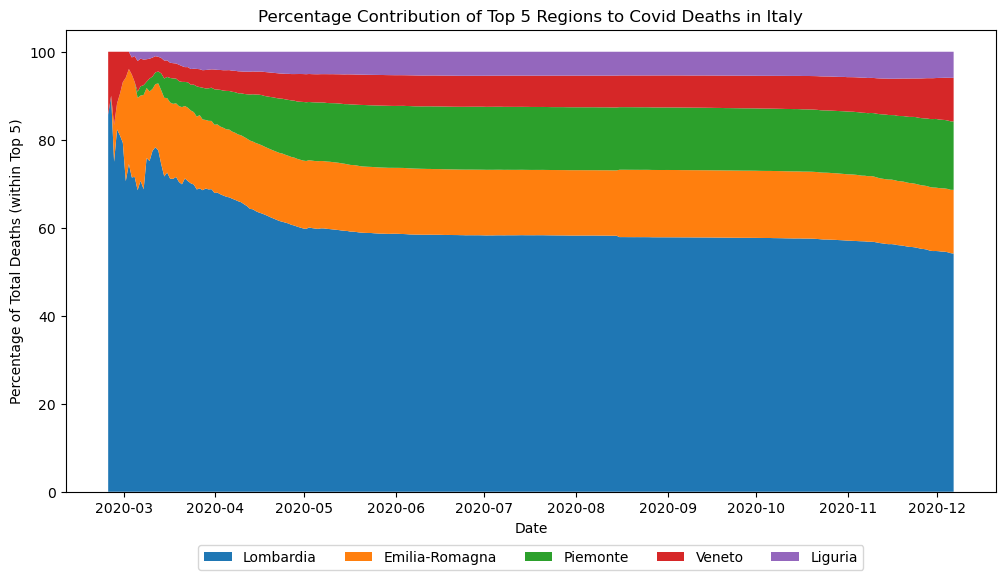

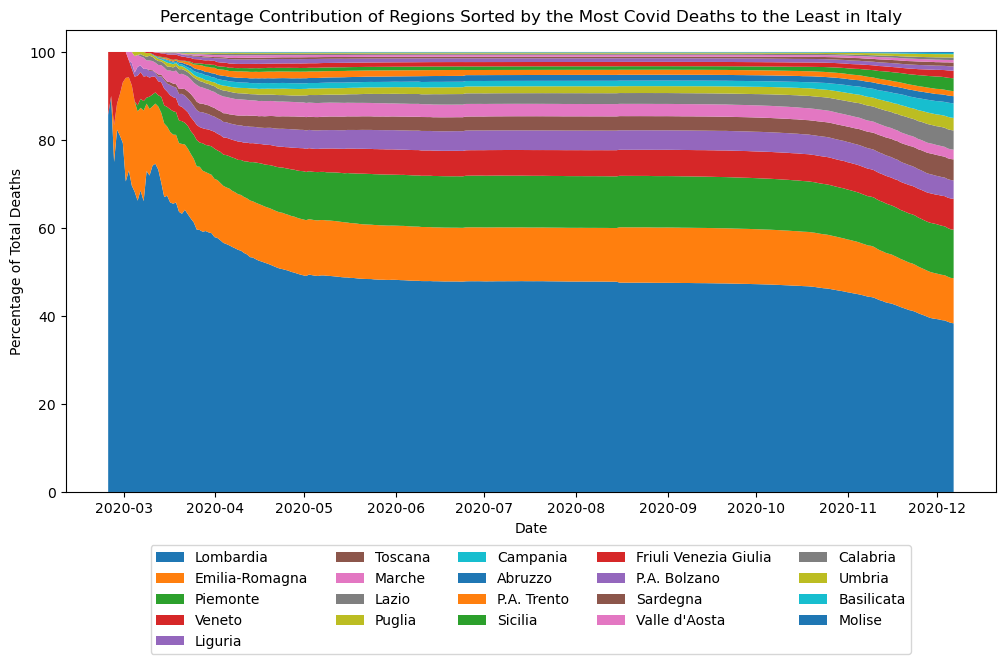

In [10]:
# create a covid dataset with date, region, and deaths
covidinitaly_deaths = covidinitaly[['Date', 'Deaths', 'RegionName']]

# pivot to wide format (date x region table)
pivot_covidinitaly_deaths = covidinitaly_deaths.pivot(index="Date",columns="RegionName",values="Deaths")

# change date index to datetime.
pivot_covidinitaly_deaths.index=pd.to_datetime(pivot_covidinitaly_deaths.index)

print(pivot_covidinitaly_deaths.shape)
print(pivot_covidinitaly_deaths.head())
print(pivot_covidinitaly_deaths.tail())
print(pivot_covidinitaly_deaths.describe().T)

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(pivot_covidinitaly_deaths.index,
              pivot_covidinitaly_deaths.T,
              labels=pivot_covidinitaly_deaths.columns)
plt.title("Covid Deaths by Region in Italy")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)
plt.show()

# select the top 5 regions in Italy with the most deaths

# find the total deaths per region
region_totals=pivot_covidinitaly_deaths.sum().sort_values(ascending=False)

# select the top 5 regions
top5_regions=region_totals.head(5).index

# filter dataframe to those regions only
top5_data=pivot_covidinitaly_deaths[top5_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top5_data.index,
              top5_data.T,
              labels=top5_data.columns)
plt.title("Covid Deaths by Top 5 Regions in Italy")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left")
plt.show()

# select top 10 regions in Italy with the most deaths

# select the top 10 regions
top10_regions=region_totals.head(10).index

# filter dataframe to those regions only
top10_data=pivot_covidinitaly_deaths[top10_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top10_data.index,
              top10_data.T,
              labels=top10_data.columns)
plt.title("Covid Deaths by Top 10 Regions in Italy")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=2)
plt.show()

# sort the regions in Italy with the most deaths to the least

# select sorted regions
sorted_regions=region_totals.head(21).index

# filter dataframe to sorted regions
sorted_data=pivot_covidinitaly_deaths[sorted_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(sorted_data.index,
              sorted_data.T,
              labels=sorted_data.columns)
plt.title("Covid Deaths Sorted by Regions with the Most Deaths to the Least in Italy")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)
plt.show()

# convert to percentages per day
covid_percent_deaths = pivot_covidinitaly_deaths.div(pivot_covidinitaly_deaths.sum(axis=1), axis=0) * 100

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(covid_percent_deaths.index,
              covid_percent_deaths.T,
              labels=covid_percent_deaths.columns)
plt.title("Percentage Contribution of Regions to Covid Deaths in Italy")
plt.ylabel("Percentage of Total Deaths")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()

# select the top N regions
N = 5
region_totals=pivot_covidinitaly_deaths.sum().sort_values(ascending=False)
topN_regions =region_totals.head(N).index

# Filter only top N regions
topN_percent = pivot_covidinitaly_deaths[topN_regions]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns)

plt.title(f"Percentage Contribution of Top {N} Regions to Covid Deaths in Italy")
plt.ylabel("Percentage of Total Deaths (within Top 5)")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()

# select the top N regions
N = 21
region_totals=pivot_covidinitaly_deaths.sum().sort_values(ascending=False)
topN_regions =region_totals.head(N).index

# Filter only top N regions
topN_percent = pivot_covidinitaly_deaths[topN_regions]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns)

plt.title("Percentage Contribution of Regions Sorted by the Most Covid Deaths to the Least in Italy")
plt.ylabel("Percentage of Total Deaths")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.savefig("italy_deaths_fig12.png", dpi=300, bbox_inches="tight")
plt.show()
